# Brocc fixed for 3 years vs AMF Räntefond Lång on Avanza

Compare a one-time lump sum held for 36 months in (1) Brocc Tillväxt with a fixed 36-month rate, (2) AMF Räntefond Lång in an ordinary fund account, and (3) the same fund in an ISK. The notebook compares the current Brocc rate with historical rolling three-year outcomes for the fund. Fund outcomes are historical illustrations, not forecasts or guaranteed returns.

Run from top to bottom. Edit the inputs below. AMF NAV history is fetched from Morningstar if the local CSV is missing; set `REFRESH_FUND_DATA = True` to request fresh NAV history. The data folder is `data/` in this project.


## Model assumptions and tax treatment

- Starts with one lump sum on a chosen date; no later deposits. Brocc interest is shown as monthly payments and is assumed not to be reinvested. Brocc principal is returned at maturity.
- Brocc's current 36-month gross rate is editable. The default, 3.30%, is the latest rate in Brocc's published rate history dated 22 September 2026. Early withdrawal is excluded; Brocc says it charges 2.5% of the amount withdrawn early.
- Avanza fund purchase/sale commission is assumed to be SEK 0. There is no separate platform fee in the model. AMF's 0.10% annual management fee is already reflected in the fund NAV and must not be deducted again. NAV history is net of fund expenses.
- Ordinary account: estimate yearly fund-share tax at 0.12% of the value on 1 January, then tax positive realized gain at 30% on sale. Loss tax offsets are not modeled.
- ISK: estimate annual tax using the editable 2026 effective rate, 1.065%. Set `APPLY_ISK_TAX_FREE_ALLOWANCE = False` to ignore the exemption, or leave it `True` and edit the remaining allowance available after other ISK/KF/PEPP savings. The 2026 exemption is up to SEK 300,000. Later-year rates and exemptions can change; keeping today's rate constant over the three-year illustration is only a scenario.
- Tax estimates assume Swedish tax residency and the stated account types. The notebook uses observed fund prices; the Brocc case assumes the advertised rate remains fixed for its 36-month term.

Current references: [Brocc fixed savings and rate history](https://brocc.se/spara/), [AMF Räntefond Lång](https://www.amf.se/spara-hos-amf/fonder/fondutbud/rantefonder/rantefond-lang/), [AMF information brochure and fees](https://www.amf.se/globalassets/pdf/rapporter/fonder/informationsbroschyr/information-om-sparande-i-amf-rantefond-lang.pdf), [Skatteverket fund taxation](https://www.skatteverket.se/privat/skatter/vardepapper/omovrigavardepapper/fonder.4.19b9f599116a9e8ef36800010782.html), and [Skatteverket ISK tax](https://www.skatteverket.se/privat/skatter/vardepapper/investeringssparkontoisk.4.5fc8c94513259a4ba1d800037851.html). Verify Brocc's current offer and Avanza's terms before investing.


In [10]:
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)
FUND_NAV_FILE = DATA_DIR / "amf_rantefond_lang_nav_sek.csv"

# Editable scenario inputs
INVESTMENT_SEK = 100_000.0
BROCC_36M_GROSS_RATE = 0.0330   # latest published rate found: 2026-09-22
BROCC_TERM_MONTHS = 36
BROCC_EARLY_WITHDRAWAL_FEE_RATE = 0.025  # disclosure only; no early withdrawal modeled
AVANZA_FUND_TRANSACTION_FEE_SEK = 0.0
AMF_ANNUAL_FEE_RATE = 0.0010    # disclosure only; already reflected in NAV
ORDINARY_FUND_SCHABLON_TAX_RATE = 0.0012  # 0.4% deemed income x 30%
CAPITAL_GAINS_TAX_RATE = 0.30
ISK_EFFECTIVE_TAX_RATE = 0.01065  # 2026 rate; update for later tax years
APPLY_ISK_TAX_FREE_ALLOWANCE = False  # False applies ISK tax to the full modeled capital base
ISK_ALLOWANCE_AVAILABLE_SEK = 300_000.0  # remaining allowance after other ISK/KF/PEPP assets
SIMULATION_START_DATE = None  # None: all available history; or YYYY-MM-DD
REFRESH_FUND_DATA = False


## Download AMF Räntefond Lång NAV history

The NAV history is used for historical rolling three-year periods. Its return already reflects the fund's ongoing expenses. This cell uses Morningstar's daily fund series; use the AMF source page above for the current fund documents and stated fee.


In [11]:
def get_bytes(url, accept="application/json"):
    req = Request(url, headers={"User-Agent": "Mozilla/5.0 SwedishBrokerComparison/1.0", "Accept": accept})
    with urlopen(req, timeout=90) as response:
        return response.read()


def refresh_fund_nav():
    candidates = ["F0GBR04K9W]2]0]FOSEK$$ALL", "F0GBR04K9W"]
    last_error = None
    for fund_id in candidates:
        params = urlencode({
            "currencyId": "SEK", "idtype": "Morningstar", "frequency": "daily",
            "outputType": "JSON", "startDate": "2000-01-01", "id": fund_id,
        })
        url = "https://lt.morningstar.com/api/rest.svc/timeseries_price/t92wz0sj7c?" + params
        try:
            payload = json.loads(get_bytes(url))
            history = payload["TimeSeries"]["Security"][0]["HistoryDetail"]
            rows = [{"date": row["EndDate"], "nav_sek": row["Value"]}
                    for row in history if row.get("Value") not in (None, "")]
            if rows:
                pd.DataFrame(rows).to_csv(FUND_NAV_FILE, index=False)
                return
        except Exception as exc:
            last_error = exc
    raise RuntimeError("Could not retrieve AMF Räntefond Lång NAV history from Morningstar.") from last_error

if REFRESH_FUND_DATA or not FUND_NAV_FILE.exists():
    refresh_fund_nav()
    print(f"Saved refreshed AMF NAV history to {FUND_NAV_FILE}")
else:
    print(f"Using cached AMF NAV history: {FUND_NAV_FILE}")

fund = pd.read_csv(FUND_NAV_FILE, parse_dates=["date"])
fund["nav_sek"] = pd.to_numeric(fund["nav_sek"], errors="coerce")
fund = (fund.dropna(subset=["date", "nav_sek"])
        .sort_values("date").drop_duplicates("date").reset_index(drop=True))
if fund.empty or (fund["nav_sek"] <= 0).any():
    raise ValueError("Fund NAV history is empty or contains invalid NAV values.")
print(f"Loaded {len(fund):,} NAV observations from {fund.date.min().date()} to {fund.date.max().date()}.")


Using cached AMF NAV history: /Users/davidezamboni/Documents/Swedish-Brokers-Comparison/data/amf_rantefond_lang_nav_sek.csv
Loaded 6,745 NAV observations from 2000-01-03 to 2026-09-23.


## Three-year return and tax comparison

Every eligible historical window starts at an observed fund NAV and ends at the first NAV on or after its three-year anniversary. The ordinary-account estimate charges the annual fund-share tax on each 1 January within the holding period and capital-gains tax at the end. The ISK estimate charges an annual flat effective rate on the estimated quarterly-average account balance above the allowance you have available. These are simplified tax estimates; precise tax depends on your full account balances and tax year.


In [12]:
if INVESTMENT_SEK <= 0 or BROCC_TERM_MONTHS <= 0:
    raise ValueError("Investment and term must be positive.")
if not 0 <= BROCC_36M_GROSS_RATE:
    raise ValueError("Brocc rate must be nonnegative.")

if SIMULATION_START_DATE:
    fund = fund.loc[fund.date >= pd.Timestamp(SIMULATION_START_DATE)].reset_index(drop=True)

# Monthly, non-reinvested interest payments; each payment is taxed at 30%.
brocc_gross_interest = INVESTMENT_SEK * BROCC_36M_GROSS_RATE * BROCC_TERM_MONTHS / 12
brocc_tax = brocc_gross_interest * CAPITAL_GAINS_TAX_RATE
brocc_net_maturity_value = INVESTMENT_SEK + brocc_gross_interest - brocc_tax


def fund_window_result(start_i):
    start_date = fund.loc[start_i, "date"]
    target_date = start_date + pd.DateOffset(months=BROCC_TERM_MONTHS)
    end_i = int(fund.date.searchsorted(target_date, side="left"))
    if end_i >= len(fund):
        return None
    end_date = fund.loc[end_i, "date"]
    start_nav = float(fund.loc[start_i, "nav_sek"])
    end_nav = float(fund.loc[end_i, "nav_sek"])
    gross_end = INVESTMENT_SEK * end_nav / start_nav

    # Approximate ordinary-account tax paid yearly from the holding, then sale tax.
    annual_tax = 0.0
    for year in range(start_date.year + 1, end_date.year + 1):
        jan1 = pd.Timestamp(year=year, month=1, day=1)
        if jan1 <= end_date:
            j = int(fund.date.searchsorted(jan1, side="right")) - 1
            if j >= start_i:
                value_jan1 = INVESTMENT_SEK * float(fund.loc[j, "nav_sek"]) / start_nav
                annual_tax += value_jan1 * ORDINARY_FUND_SCHABLON_TAX_RATE
    ordinary_before_sale = max(0.0, gross_end - annual_tax)
    ordinary_gain = max(0.0, ordinary_before_sale - INVESTMENT_SEK)
    ordinary_sale_tax = ordinary_gain * CAPITAL_GAINS_TAX_RATE
    ordinary_net = ordinary_before_sale - ordinary_sale_tax - AVANZA_FUND_TRANSACTION_FEE_SEK

    # Estimate ISK capital base from quarter-start values plus the deposit rule.
    isk_tax = 0.0
    for year in range(start_date.year, end_date.year + 1):
        year_start = pd.Timestamp(year=year, month=1, day=1)
        year_end = min(pd.Timestamp(year=year + 1, month=1, day=1), end_date)
        if year_end <= start_date or year_start > end_date:
            continue
        quarter_values = []
        for month in (1, 4, 7, 10):
            q_date = pd.Timestamp(year=year, month=month, day=1)
            if start_date < q_date <= end_date:
                qidx = int(fund.date.searchsorted(q_date, side="right")) - 1
                if qidx >= start_i:
                    quarter_values.append(INVESTMENT_SEK * float(fund.loc[qidx, "nav_sek"]) / start_nav)
            elif q_date < start_date and year == start_date.year:
                quarter_values.append(0.0)
        # Statutory capital base includes deposits during the tax year, divided by four.
        deposits_this_year = INVESTMENT_SEK if year == start_date.year else 0.0
        capital_base = (sum(quarter_values) + deposits_this_year) / 4.0
        allowance_for_this_scenario = ISK_ALLOWANCE_AVAILABLE_SEK if APPLY_ISK_TAX_FREE_ALLOWANCE else 0.0
        taxable_base = max(0.0, capital_base - allowance_for_this_scenario)
        isk_tax += taxable_base * ISK_EFFECTIVE_TAX_RATE
    isk_net = gross_end - isk_tax - AVANZA_FUND_TRANSACTION_FEE_SEK

    return {
        "start_date": start_date, "end_date": end_date,
        "gross_return_pct": (gross_end / INVESTMENT_SEK - 1) * 100,
        "ordinary_net_sek": ordinary_net,
        "ordinary_total_tax_sek": annual_tax + ordinary_sale_tax,
        "isk_net_sek": isk_net,
        "isk_tax_sek": isk_tax,
        "fund_gross_end_sek": gross_end,
    }

results = [fund_window_result(i) for i in range(len(fund))]
rolling = pd.DataFrame([r for r in results if r is not None])
if rolling.empty:
    raise ValueError("Not enough NAV history for a three-year window.")

latest_window = rolling.sort_values("end_date").iloc[-1]
summary = pd.DataFrame([
    {"option": "Brocc Tillväxt fixed 36 months (current rate)",
     "net_end_value_sek": brocc_net_maturity_value,
     "total_tax_sek": brocc_tax,
     "historical_3y_windows": "Current rate illustration"},
    {"option": "AMF ordinary account (latest trailing window)",
     "net_end_value_sek": latest_window.ordinary_net_sek,
     "total_tax_sek": latest_window.ordinary_total_tax_sek,
     "historical_3y_windows": f"{latest_window.start_date.date()} to {latest_window.end_date.date()}"},
    {"option": "AMF ordinary account (historical median)",
     "net_end_value_sek": rolling.ordinary_net_sek.median(),
     "total_tax_sek": rolling.ordinary_total_tax_sek.median(),
     "historical_3y_windows": f"Median of {len(rolling):,} historical windows"},
    {"option": "AMF ISK (latest trailing window)",
     "net_end_value_sek": latest_window.isk_net_sek,
     "total_tax_sek": latest_window.isk_tax_sek,
     "historical_3y_windows": f"{latest_window.start_date.date()} to {latest_window.end_date.date()}"},
    {"option": "AMF ISK (historical median)",
     "net_end_value_sek": rolling.isk_net_sek.median(),
     "total_tax_sek": rolling.isk_tax_sek.median(),
     "historical_3y_windows": f"Median of {len(rolling):,} historical windows"},
])
summary["net_profit_sek"] = summary.net_end_value_sek - INVESTMENT_SEK
display(summary.style.format({
    "net_end_value_sek": "SEK {:,.0f}", "net_profit_sek": "SEK {:,.0f}",
    "total_tax_sek": "SEK {:,.0f}",
}))
print(f"Brocc monthly interest payment before tax: SEK {INVESTMENT_SEK * BROCC_36M_GROSS_RATE / 12:,.2f}")
print(f"Brocc total interest after estimated 30% tax: SEK {brocc_gross_interest - brocc_tax:,.0f}")


,option,net_end_value_sek,total_tax_sek,historical_3y_windows,net_profit_sek
0,Brocc Tillväxt fixed 36 months (current rate),"SEK 106,930","SEK 2,970",Current rate illustration,"SEK 6,930"
1,AMF ordinary account (latest trailing window),"SEK 109,020","SEK 4,257",2023-09-22 to 2026-09-22,"SEK 9,020"
2,AMF ordinary account (historical median),"SEK 102,969","SEK 1,642","Median of 5,994 historical windows","SEK 2,969"
3,AMF ISK (latest trailing window),"SEK 109,526","SEK 3,751",2023-09-22 to 2026-09-22,"SEK 9,526"
4,AMF ISK (historical median),"SEK 101,071","SEK 3,543","Median of 5,994 historical windows","SEK 1,071"


Brocc monthly interest payment before tax: SEK 275.00
Brocc total interest after estimated 30% tax: SEK 6,930


## Historical range and chart

The shaded distribution illustrates how the fund's three-year outcomes have varied. Brocc's line is the maturity value using the current fixed rate. Compare outcomes as scenarios rather than assuming the fund will repeat a past period.


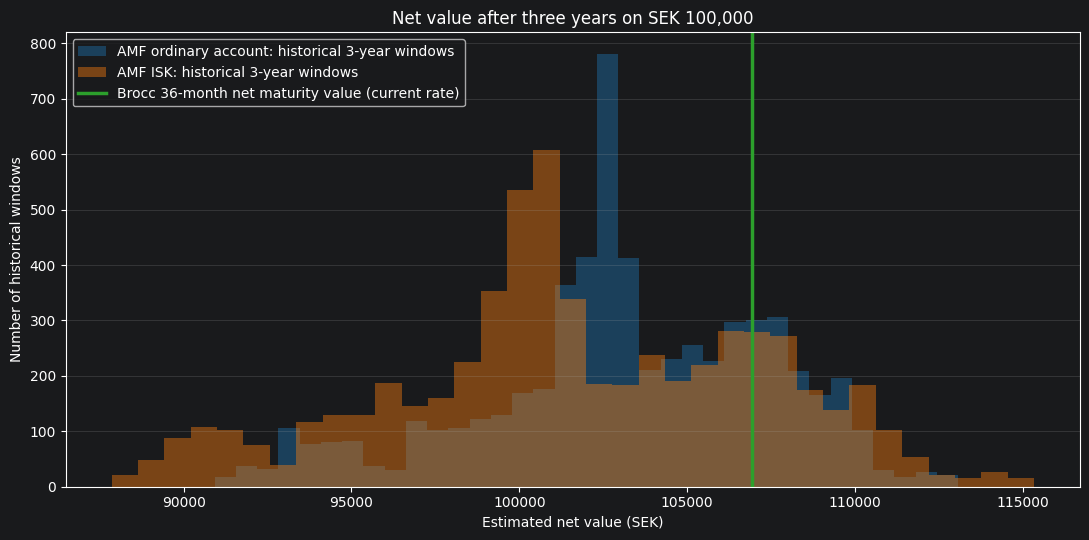

,AMF ordinary net value (SEK),AMF ISK net value (SEK)
5th percentile,"94,385","91,313"
25th percentile,"101,200","98,622"
Median,"102,969","101,071"
75th percentile,"106,536","106,090"
95th percentile,"109,589","110,367"


Historical windows run from 2000-01-03 to 2026-09-22.


In [13]:
fund_options = [
    ("AMF ordinary account", "ordinary_net_sek", "#1f77b4"),
    ("AMF ISK", "isk_net_sek", "#ff7f0e"),
]
fig, ax = plt.subplots(figsize=(11, 5.5))
for label, column, color in fund_options:
    ax.hist(rolling[column], bins=35, alpha=0.42, label=f"{label}: historical 3-year windows", color=color)
ax.axvline(brocc_net_maturity_value, color="#2ca02c", linewidth=2.5,
           label="Brocc 36-month net maturity value (current rate)")
ax.set(title=f"Net value after three years on SEK {INVESTMENT_SEK:,.0f}",
       xlabel="Estimated net value (SEK)", ylabel="Number of historical windows")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

range_table = rolling[["ordinary_net_sek", "isk_net_sek"]].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).rename(index={
    0.05: "5th percentile", 0.25: "25th percentile", 0.50: "Median", 0.75: "75th percentile", 0.95: "95th percentile"
}).rename(columns={"ordinary_net_sek": "AMF ordinary net value (SEK)", "isk_net_sek": "AMF ISK net value (SEK)"})
display(range_table.style.format("{:,.0f}"))
print(f"Historical windows run from {rolling.start_date.min().date()} to {rolling.end_date.max().date()}.")


## Cost and limitation summary

| Item | Brocc fixed 36 months | AMF on Avanza ordinary account | AMF on Avanza ISK |
|---|---|---|---|
| Product/platform fee | No account fee modeled | Avanza fund trades assumed commission-free | Avanza fund trades assumed commission-free |
| Fund fee | Not applicable | 0.10%/year, embedded in NAV | 0.10%/year, embedded in NAV |
| Tax | 30% on interest income | 0.12% annual fund-share tax plus 30% tax on positive realized gain | Annual ISK tax; toggle the 2026 exemption in the inputs |
| Capital protection | Deposit terms and Swedish deposit guarantee; check current terms and your total covered balance | No capital guarantee; fund NAV can fall | No capital guarantee; fund NAV can fall |
| Liquidity | Early withdrawal fee stated as 2.5% | Fund sale subject to dealing/settlement | Fund sale subject to dealing/settlement |

Brocc's published history says monthly interest payments and lists the 36-month rate, while early withdrawal incurs a fee. This model does not discount monthly interest payments or assume reinvestment. AMF Räntefond Lång owns bonds and can gain or lose value as interest rates and credit spreads move; its NAV is not a fixed-rate deposit. Tax rules and rates are personal and may change during the three-year period. The ISK estimate applies the entered remaining exemption only when `APPLY_ISK_TAX_FREE_ALLOWANCE = True`; when False, it taxes the full modeled capital base. It does not model other ISK holdings' full quarterly valuation.


## Dynamic conclusion

This section ranks the three choices by modeled net ending value using the current Brocc rate and the median historical three-year outcomes for AMF. It also reports which AMF account type did better in the latest trailing three-year window. The ranking updates when the notebook is rerun after changing the tax switch, tax allowance, rate, investment amount, or NAV data.


In [14]:
median_values = pd.Series({
    "Brocc Tillväxt fixed 36 months (current rate)": brocc_net_maturity_value,
    "AMF Räntefond Lång on Avanza (ordinary account, historical median)": rolling.ordinary_net_sek.median(),
    "AMF Räntefond Lång on Avanza ISK (historical median)": rolling.isk_net_sek.median(),
}, name="Net ending value (SEK)").sort_values(ascending=False)

latest_values = pd.Series({
    "AMF ordinary account": latest_window.ordinary_net_sek,
    "AMF ISK": latest_window.isk_net_sek,
}, name="Net ending value (SEK)").sort_values(ascending=False)

print("Median historical comparison plus current Brocc rate:")
display(median_values.to_frame().style.format("SEK {:,.0f}"))
best_option = median_values.index[0]
second_option = median_values.index[1]
advantage = median_values.iloc[0] - median_values.iloc[1]
latest_best = latest_values.index[0]
allowance_status = (
    f"The ISK tax-free allowance is included (SEK {ISK_ALLOWANCE_AVAILABLE_SEK:,.0f} available)."
    if APPLY_ISK_TAX_FREE_ALLOWANCE
    else "The ISK tax-free allowance is switched off; the full modeled ISK capital base is taxed."
)

from IPython.display import Markdown
display(Markdown(
    f"**Highest modeled net ending value:** {best_option}, at SEK {median_values.iloc[0]:,.0f} "
    f"for a SEK {INVESTMENT_SEK:,.0f} starting investment. It is SEK {advantage:,.0f} above "
    f"{second_option}, the next-highest option under these inputs.\n\n"
    f"**Latest trailing fund window ({latest_window.start_date.date()} to {latest_window.end_date.date()}):** "
    f"{latest_best} had the higher estimated after-tax value (SEK {latest_values.iloc[0]:,.0f}). "
    f"{allowance_status}\n\n"
    "This is a ranking by modeled after-tax value, not a forecast or a universal recommendation. "
    "The fund figures are historical and can include losses; Brocc uses the current fixed rate, "
    "which is shown assuming the deposit is held to maturity and qualifies for the applicable deposit guarantee."
))


Median historical comparison plus current Brocc rate:


,Net ending value (SEK)
Brocc Tillväxt fixed 36 months (current rate),"SEK 106,930"
"AMF Räntefond Lång on Avanza (ordinary account, historical median)","SEK 102,969"
AMF Räntefond Lång on Avanza ISK (historical median),"SEK 101,071"


**Highest modeled net ending value:** Brocc Tillväxt fixed 36 months (current rate), at SEK 106,930 for a SEK 100,000 starting investment. It is SEK 3,961 above AMF Räntefond Lång on Avanza (ordinary account, historical median), the next-highest option under these inputs.

**Latest trailing fund window (2023-09-22 to 2026-09-22):** AMF ISK had the higher estimated after-tax value (SEK 109,526). The ISK tax-free allowance is switched off; the full modeled ISK capital base is taxed.

This is a ranking by modeled after-tax value, not a forecast or a universal recommendation. The fund figures are historical and can include losses; Brocc uses the current fixed rate, which is shown assuming the deposit is held to maturity and qualifies for the applicable deposit guarantee.